In [ ]:
from google.colab import files
uploaded = files.upload()

KeyboardInterrupt: 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/bangladesh_student_performance[1].csv')

In [ ]:
df['Average_Score'] = df[['Previous_GPA', 'SSC_Result', 'HSC_Result']].mean(axis=1)

def categorize_performance(score):
    if score >= 4.5:
        return 'A'
    elif 3.5 <= score < 4.5:
        return 'B'
    else:
        return 'C'

df['Performance_Category'] = df['Average_Score'].apply(categorize_performance)

display(df[['Previous_GPA', 'SSC_Result', 'HSC_Result', 'Average_Score', 'Performance_Category']].head())
display(df['Performance_Category'].value_counts())

,Previous_GPA,SSC_Result,HSC_Result,Average_Score,Performance_Category
0,4.83,4.22,5.00,4.683333,A
1,4.96,4.09,4.77,4.606667,A
2,4.32,4.86,4.62,4.600000,A
3,4.63,3.54,3.75,3.973333,B
4,4.50,4.65,3.46,4.203333,B


,count
Performance_Category,
B,873
A,99
C,28


In [ ]:
df_processed = df.drop('Student_ID', axis=1)

features_to_drop_from_input = ['Previous_GPA', 'SSC_Result', 'HSC_Result', 'Average_Score']
df_processed = df_processed.drop(columns=features_to_drop_from_input, errors='ignore')

print("DataFrame after dropping Student_ID and features used for target creation:")
display(df_processed.head())

DataFrame after dropping Student_ID and features used for target creation:


,Gender,Age,District,School_Type,Study_Hours_per_Week,Attendance,Parent_Education,Family_Income_BDT,Internet_Access,Private_Tuition,Performance_Category
0,Male,16,Rangpur,Private,11,70,Graduate,49169,Yes,Yes,A
1,Female,17,Rajshahi,Private,7,76,Primary,57947,No,No,A
2,Male,15,Barisal,Private,27,63,Higher Secondary,57224,Yes,Yes,A
3,Male,15,Mymensingh,Private,18,84,Primary,55865,No,No,B
4,Male,15,Mymensingh,Public,28,89,Higher Secondary,35553,No,Yes,B


In [ ]:
from sklearn.preprocessing import LabelEncoder

X = df_processed.drop('Performance_Category', axis=1)
y = df_processed['Performance_Category']

categorical_cols = X.select_dtypes(include=['object']).columns

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    print(f"Encoded column '{col}': {le.classes_}")

le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)
print(f"Encoded target labels: {le_target.classes_}")

print("\nFeatures after categorical encoding:")
display(X.head())
print("\nTarget after encoding:")
display(y_encoded[:5])

Encoded column 'Gender': ['Female' 'Male']
Encoded column 'District': ['Barisal' 'Chattogram' 'Dhaka' 'Khulna' 'Mymensingh' 'Rajshahi' 'Rangpur'
 'Sylhet']
Encoded column 'School_Type': ['Private' 'Public']
Encoded column 'Parent_Education': ['Graduate' 'Higher Secondary' 'Primary' 'Secondary']
Encoded column 'Internet_Access': ['No' 'Yes']
Encoded column 'Private_Tuition': ['No' 'Yes']
Encoded target labels: ['A' 'B' 'C']

Features after categorical encoding:


,Gender,Age,District,School_Type,Study_Hours_per_Week,Attendance,Parent_Education,Family_Income_BDT,Internet_Access,Private_Tuition
0,1,16,6,0,11,70,0,49169,1,1
1,0,17,5,0,7,76,2,57947,0,0
2,1,15,0,0,27,63,1,57224,1,1
3,1,15,4,0,18,84,2,55865,0,0
4,1,15,4,1,28,89,1,35553,0,1



Target after encoding:


array([0, 0, 0, 1, 1])

In [ ]:
missing_values = X.isnull().sum()
print("Missing values in features (X):\n", missing_values[missing_values > 0])

missing_values_target = pd.Series(y_encoded).isnull().sum()
print("Missing values in target (y): ", missing_values_target)

if missing_values.sum() == 0 and missing_values_target == 0:
    print("No missing values found in the dataset.")
else:
    print("Missing values detected. Further handling might be required.")

Missing values in features (X):
 Series([], dtype: int64)
Missing values in target (y):  0
No missing values found in the dataset.


In [ ]:
from sklearn.preprocessing import StandardScaler

numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[numerical_cols] = scaler.fit_transform(X_scaled[numerical_cols])

print("Features after standardization:")
display(X_scaled.head())

X_processed = X_scaled
y_processed = y_encoded

Features after standardization:


,Gender,Age,District,School_Type,Study_Hours_per_Week,Attendance,Parent_Education,Family_Income_BDT,Internet_Access,Private_Tuition
0,1.020204,-0.378149,1.128657,-0.953099,-0.836789,-0.820323,-1.293980,0.983759,1.045012,0.994018
1,-0.980196,0.535254,0.689662,-0.953099,-1.385323,-0.296824,0.476170,1.588457,-0.956927,-1.006018
2,1.020204,-1.291551,-1.505315,-0.953099,1.357348,-1.431071,-0.408905,1.538651,1.045012,0.994018
3,1.020204,-1.291551,0.250666,-0.953099,0.123146,0.401175,0.476170,1.445032,-0.956927,-1.006018
4,1.020204,-1.291551,0.250666,1.049209,1.494482,0.837424,-0.408905,0.045782,-0.956927,0.994018


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_processed, y_processed, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (800, 10)
X_test shape: (200, 10)
y_train shape: (800,)
y_test shape: (200,)


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm_linear = SVC(kernel='linear', random_state=42)
svm_rbf = SVC(kernel='rbf', random_state=42)
svm_poly = SVC(kernel='poly', degree=3, random_state=42)

print("Training Linear SVM...")
svm_linear.fit(X_train, y_train)
print("Training RBF SVM...")
svm_rbf.fit(X_train, y_train)
print("Training Polynomial SVM...")
svm_poly.fit(X_train, y_train)

y_pred_linear = svm_linear.predict(X_test)
y_pred_rbf = svm_rbf.predict(X_test)
y_pred_poly = svm_poly.predict(X_test)

accuracy_linear = accuracy_score(y_test, y_pred_linear)
accuracy_rbf = accuracy_score(y_test, y_pred_rbf)
accuracy_poly = accuracy_score(y_test, y_pred_poly)

print(f"\nAccuracy (Linear Kernel): {accuracy_linear:.4f}")
print(f"Accuracy (RBF Kernel): {accuracy_rbf:.4f}")
print(f"Accuracy (Polynomial Kernel): {accuracy_poly:.4f}")

accuracies = {
    'Linear': accuracy_linear,
    'RBF': accuracy_rbf,
    'Polynomial': accuracy_poly
}
best_kernel = max(accuracies, key=accuracies.get)
best_accuracy = accuracies[best_kernel]

print(f"\nBest performing kernel: {best_kernel} with an accuracy of {best_accuracy:.4f}")

if best_kernel == 'Linear':
    best_svm_model = svm_linear
elif best_kernel == 'RBF':
    best_svm_model = svm_rbf
else:
    best_svm_model = svm_poly

Training Linear SVM...
Training RBF SVM...
Training Polynomial SVM...

Accuracy (Linear Kernel): 0.8700
Accuracy (RBF Kernel): 0.8700
Accuracy (Polynomial Kernel): 0.8700

Best performing kernel: Linear with an accuracy of 0.8700


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred_best = best_svm_model.predict(X_test)

print(f"### Evaluation for the Best SVM Model ({best_kernel} Kernel) ###")

accuracy = accuracy_score(y_test, y_pred_best)
print(f"\nAccuracy Score: {accuracy:.4f}")

conf_matrix = confusion_matrix(y_test, y_pred_best)
print("\nConfusion Matrix:")
print(conf_matrix)

class_report = classification_report(y_test, y_pred_best, target_names=le_target.classes_)
print("\nClassification Report:")
print(class_report)

### Evaluation for the Best SVM Model (Linear Kernel) ###

Accuracy Score: 0.8700

Confusion Matrix:
[[  0  19   0]
 [  0 174   0]
 [  0   7   0]]

Classification Report:
              precision    recall  f1-score   support

           A       0.00      0.00      0.00        19
           B       0.87      1.00      0.93       174
           C       0.00      0.00      0.00         7

    accuracy                           0.87       200
   macro avg       0.29      0.33      0.31       200
weighted avg       0.76      0.87      0.81       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler


new_student_data = {
    'Gender': ['Male'],
    'Age': [16],
    'District': ['Dhaka'],
    'School_Type': ['Public'],
    'Study_Hours_per_Week': [15],
    'Attendance': [85],
    'Parent_Education': ['Graduate'],
    'Family_Income_BDT': [60000],
    'Internet_Access': ['Yes'],
    'Private_Tuition': ['No']
}

new_student_df = pd.DataFrame(new_student_data)
display("New student raw data:", new_student_df)

X_original = df_processed.drop('Performance_Category', axis=1)

for col in X_original.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    le.fit(X_original[col])
    new_student_df[col] = le.transform(new_student_df[col])

numerical_cols_new = new_student_df.select_dtypes(include=['int64', 'float64']).columns
new_student_scaled = new_student_df.copy()
new_student_scaled[numerical_cols_new] = scaler.transform(new_student_scaled[numerical_cols_new])

display("New student preprocessed data:", new_student_scaled)

predicted_category_encoded = best_svm_model.predict(new_student_scaled)

predicted_category_label = le_target.inverse_transform(predicted_category_encoded)

print(f"\nPredicted Performance Category: {predicted_category_label[0]} ({le_target.classes_[predicted_category_encoded[0]]})\n")

'New student raw data:'

,Gender,Age,District,School_Type,Study_Hours_per_Week,Attendance,Parent_Education,Family_Income_BDT,Internet_Access,Private_Tuition
0,Male,16,Dhaka,Public,15,85,Graduate,60000,Yes,No


'New student preprocessed data:'

,Gender,Age,District,School_Type,Study_Hours_per_Week,Attendance,Parent_Education,Family_Income_BDT,Internet_Access,Private_Tuition
0,1.020204,-0.378149,-0.627324,1.049209,-0.288255,0.488424,-1.29398,1.729884,1.045012,-1.006018



Predicted Performance Category: B (B)



In [ ]:
df = pd.read_csv('/content/bangladesh_student_performance[1].csv')

/tmp/ipykernel_582/810117320.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Performance_Category', order=['A', 'B', 'C'], palette='viridis')


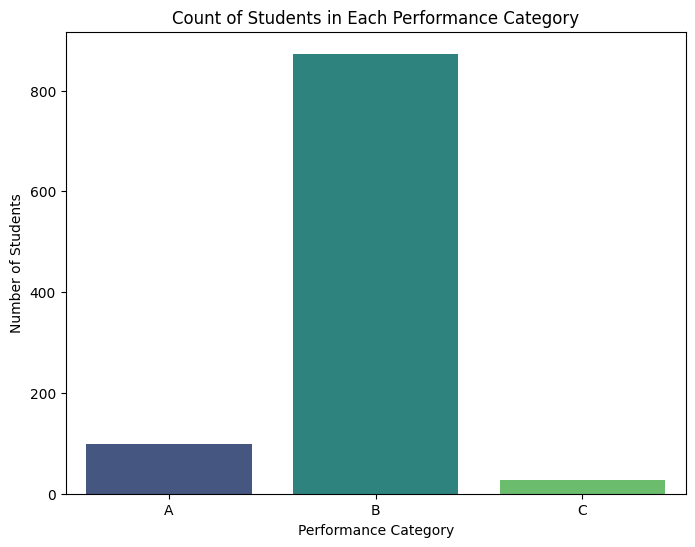

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Performance_Category', order=['A', 'B', 'C'], palette='viridis')
plt.title('Count of Students in Each Performance Category')
plt.xlabel('Performance Category')
plt.ylabel('Number of Students')
plt.show()

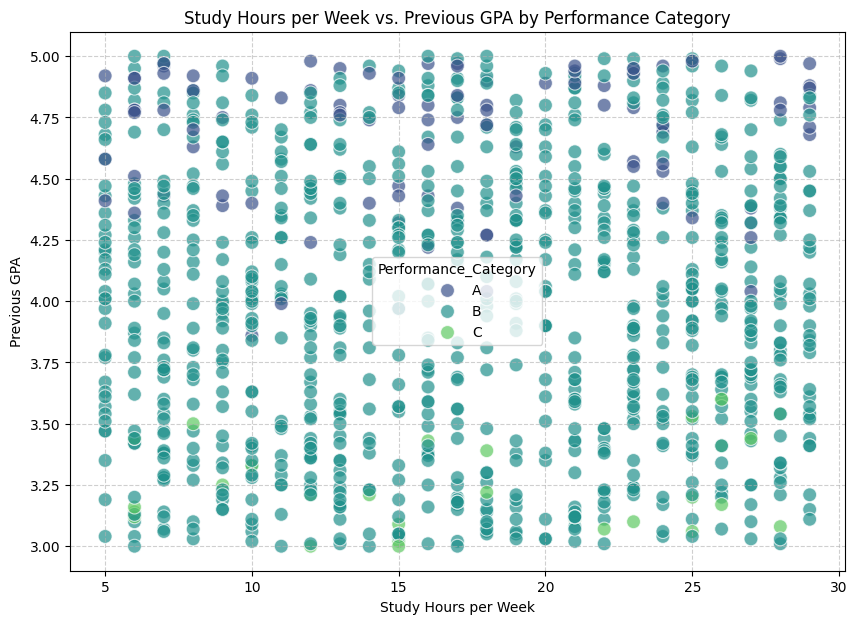

In [ ]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='Study_Hours_per_Week', y='Previous_GPA', hue='Performance_Category', palette='viridis', s=100, alpha=0.7)
plt.title('Study Hours per Week vs. Previous GPA by Performance Category')
plt.xlabel('Study Hours per Week')
plt.ylabel('Previous GPA')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

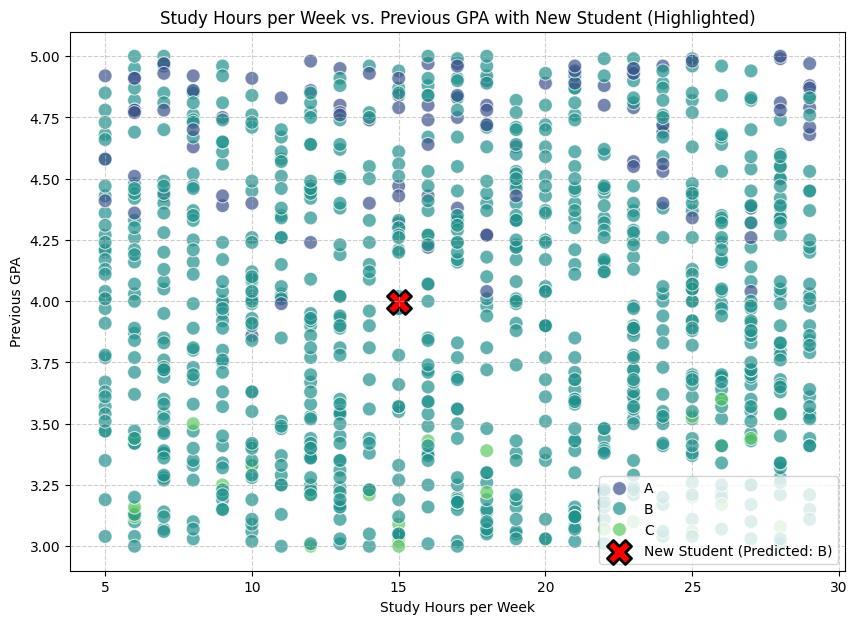

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

avg_previous_gpa = df['Previous_GPA'].mean()

new_student_study_hours = new_student_data['Study_Hours_per_Week'][0]
predicted_new_category = predicted_category_label[0]

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='Study_Hours_per_Week', y='Previous_GPA', hue='Performance_Category', palette='viridis', s=100, alpha=0.7)

plt.scatter(new_student_study_hours, avg_previous_gpa,
            color='red', marker='X', s=300, edgecolor='black', linewidth=2,
            label=f'New Student (Predicted: {predicted_new_category})')

plt.title('Study Hours per Week vs. Previous GPA with New Student (Highlighted)')
plt.xlabel('Study Hours per Week')
plt.ylabel('Previous GPA')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

In [ ]:
import joblib

model_filename = 'best_svm_model.joblib'

joblib.dump(best_svm_model, model_filename)

print(f"Best SVM model saved as '{model_filename}'")

loaded_svm_model = joblib.load(model_filename)

print(f"Model '{model_filename}' loaded successfully.")

predicted_category_encoded_loaded = loaded_svm_model.predict(new_student_scaled)
predicted_category_label_loaded = le_target.inverse_transform(predicted_category_encoded_loaded)

print(f"\nPredicted Performance Category with loaded model: {predicted_category_label_loaded[0]} ({le_target.classes_[predicted_category_encoded_loaded[0]]})")

Best SVM model saved as 'best_svm_model.joblib'
Model 'best_svm_model.joblib' loaded successfully.

Predicted Performance Category with loaded model: B (B)


In [ ]:
df.shape

(1000, 16)